# Deep Learning-Based Detection of Population-Level Stress Signals in Social Media
## Week 3 - Milestone B: Initial Notebook

**Student:** Matt Romero  
**Course:** AIT-716 Advanced Artificial Intelligence  
**Date:** July 19, 2026  

This notebook establishes the preliminary technical foundation for the project before model training begins in Milestone C. First, I imported the required Python packages and configured a consistent random seed to support reproducibility. I then loaded the Dreaddit training and testing datasets and inspected their structure, including the number of records, available features, missing values, duplicate text, label distribution, and possible overlap between the training and testing data.

Next, I performed preliminary preprocessing by applying limited text normalization, such as replacing URLs and removing unnecessary whitespace, while preserving punctuation, negation, and emotionally meaningful language. I also reviewed text-length patterns, created a stratified training and validation split, and calculated potential class weights to determine whether class imbalance would need additional treatment.

Finally, I outlined the next steps for Milestone C, which will include tokenizing the text with DistilBERT, fine-tuning the model, monitoring training and validation performance, and comparing the results against simpler baseline models. The notebook does not train the model yet; its purpose is to confirm that the data, environment, and preprocessing workflow are ready for model development.


## 1. Environment Setup

The cells belowimport the packages needed for dataset inspection and preliminary preprocessing. The `transformers` library is referenced for Milestone C but the model is not trained here.


In [1]:
from pathlib import Path
import sys
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print("Random seed:", SEED)


Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
Random seed: 42


## 2. Dataset Loading

The notebook first looks for `dreaddit-train.csv` and `dreaddit-test.csv` in the notebook directory. In Colab, upload both files before running. A public raw-file fallback is included for reproducibility.


In [2]:
DATA_DIR = Path(".")
TRAIN_FILE = DATA_DIR / "dreaddit-train.csv"
TEST_FILE = DATA_DIR / "dreaddit-test.csv"

TRAIN_URL = "https://raw.githubusercontent.com/zhixin-lim/DSA4262/main/Individual%20Assignment%202/data/dreaddit-train.csv"
TEST_URL = "https://raw.githubusercontent.com/zhixin-lim/DSA4262/main/Individual%20Assignment%202/data/dreaddit-test.csv"

def load_csv(local_path: Path, fallback_url: str) -> pd.DataFrame:
    if local_path.exists():
        return pd.read_csv(local_path)
    print(f"{local_path.name} was not found locally; loading the public fallback URL.")
    return pd.read_csv(fallback_url)

train_df = load_csv(TRAIN_FILE, TRAIN_URL)
test_df = load_csv(TEST_FILE, TEST_URL)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)


dreaddit-train.csv was not found locally; loading the public fallback URL.
dreaddit-test.csv was not found locally; loading the public fallback URL.
Training shape: (2838, 116)
Test shape: (715, 116)


In [3]:
train_df.head(3)[["subreddit", "text", "label", "confidence"]]


,subreddit,text,label,confidence
0,ptsd,"He said he had not felt that way before, sugge...",1,0.8
1,assistance,"Hey there r/assistance, Not sure if this is th...",0,1.0
2,ptsd,My mom then hit me with the newspaper and it s...,1,0.8


## 3. Dataset Structure and QA

In [4]:
print("Number of training instances:", len(train_df))
print("Number of test instances:", len(test_df))
print("Total labeled instances:", len(train_df) + len(test_df))
print("Number of columns:", train_df.shape[1])
print("\nFirst 15 columns:")
print(train_df.columns[:15].tolist())


Number of training instances: 2838
Number of test instances: 715
Total labeled instances: 3553
Number of columns: 116

First 15 columns:
['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label', 'confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone']


In [5]:
summary = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing_train": train_df.isna().sum(),
    "missing_test": test_df.isna().sum()
})
summary.head(20)


,dtype,missing_train,missing_test
confidence,float64,0,0
id,int64,0,0
label,int64,0,0
lex_dal_avg_activation,float64,0,0
lex_dal_avg_imagery,float64,0,0
lex_dal_avg_pleasantness,float64,0,0
lex_dal_max_activation,float64,0,0
lex_dal_max_imagery,float64,0,0
lex_dal_max_pleasantness,float64,0,0
lex_dal_min_activation,float64,0,0


In [6]:
quality_checks = pd.Series({
    "missing training text": train_df["text"].isna().sum(),
    "missing test text": test_df["text"].isna().sum(),
    "duplicate training text": train_df.duplicated(subset=["text"]).sum(),
    "duplicate test text": test_df.duplicated(subset=["text"]).sum(),
    "train/test overlapping text": len(set(train_df["text"]).intersection(set(test_df["text"]))),
    "unexpected training labels": (~train_df["label"].isin([0, 1])).sum(),
    "unexpected test labels": (~test_df["label"].isin([0, 1])).sum(),
})
quality_checks.to_frame("count")


,count
missing training text,0
missing test text,0
duplicate training text,18
duplicate test text,0
train/test overlapping text,3
unexpected training labels,0
unexpected test labels,0


The duplicate and overlap checks are important because identical text in more than one split could inflate performance. Any overlap found should be investigated before Milestone C. Identifiers and social metadata will not be used as primary model inputs.


The initial quality checks identified a small number of duplicate text records within the training data, along with a few instances of text appearing in both the training and test sets. These records could create data leakage by allowing the model to encounter the same language during training and final evaluation, which may make performance appear stronger than it actually is.

Before training begins in Milestone C, the duplicate records will be reviewed to determine whether they represent exact copies, repeated annotations, or legitimately distinct examples. Exact duplicates will be removed from the training data, and any text overlapping between the training and test sets will be excluded from the training split so the held-out test set remains independent. The final dataset counts and any changes made during this process will be documented to preserve reproducibility.

## 4. Label Distribution

In [7]:
label_table = pd.DataFrame({
    "train_count": train_df["label"].value_counts().sort_index(),
    "test_count": test_df["label"].value_counts().sort_index()
})
label_table["total"] = label_table.sum(axis=1)
label_table["total_percent"] = (label_table["total"] / label_table["total"].sum() * 100).round(2)
label_table.index = ["Non-stress (0)", "Stress (1)"]
label_table


,train_count,test_count,total,total_percent
Non-stress (0),1350,346,1696,47.73
Stress (1),1488,369,1857,52.27


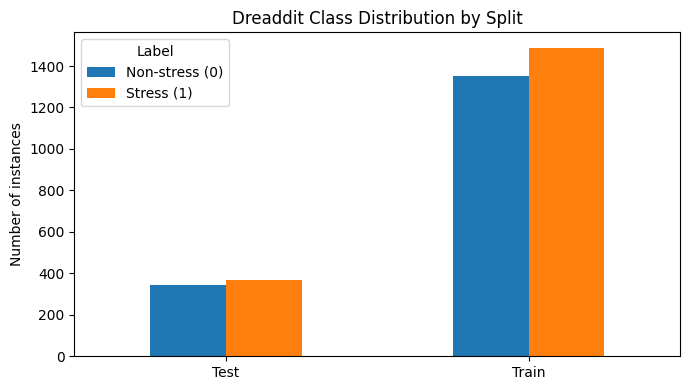

In [8]:
combined = pd.concat(
    [train_df.assign(split="Train"), test_df.assign(split="Test")],
    ignore_index=True
)

plot_counts = combined.groupby(["split", "label"]).size().unstack(fill_value=0)
ax = plot_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Dreaddit Class Distribution by Split")
ax.set_xlabel("")
ax.set_ylabel("Number of instances")
ax.legend(["Non-stress (0)", "Stress (1)"], title="Label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Text-Length Inspection

In [9]:
def basic_word_count(text: str) -> int:
    return len(str(text).split())

for frame in (train_df, test_df):
    frame["word_count"] = frame["text"].map(basic_word_count)
    frame["char_count"] = frame["text"].astype(str).str.len()

length_summary = pd.concat([
    train_df["word_count"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).rename("train"),
    test_df["word_count"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).rename("test")
], axis=1)
length_summary


,train,test
count,2838.000000,715.000000
mean,85.669838,85.448951
std,32.292305,31.228643
min,1.000000,12.000000
50%,80.000000,81.000000
75%,101.000000,101.000000
90%,126.300000,126.000000
95%,143.000000,144.300000
99%,189.630000,175.860000
max,310.000000,268.000000


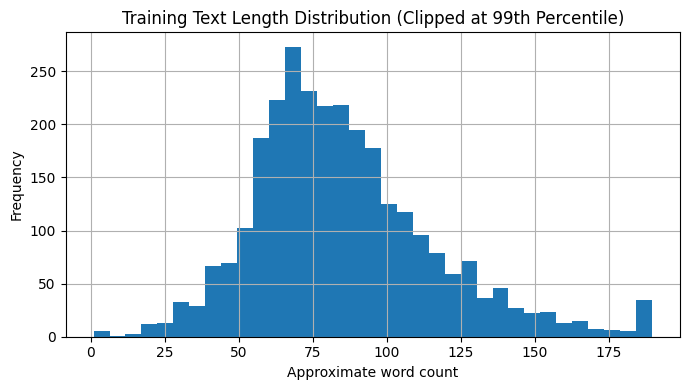

In [10]:
ax = train_df["word_count"].clip(upper=train_df["word_count"].quantile(0.99)).hist(
    bins=35, figsize=(7, 4)
)
ax.set_title("Training Text Length Distribution (Clipped at 99th Percentile)")
ax.set_xlabel("Approximate word count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


A preliminary maximum sequence length of **256 subword tokens** is proposed. The exact value will be confirmed with the DistilBERT tokenizer in Milestone C. Truncation creates a risk of losing late-post context, so the token-length percentiles and truncated examples will be reviewed before training.


## 6. Preliminary Text Preprocessing

In [15]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
WHITESPACE_PATTERN = re.compile(r"\s+")

def normalize_text(text: str) -> str:
    """Apply conservative normalization without removing stress-related language."""
    text = str(text)
    text = URL_PATTERN.sub("[URL]", text)
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].map(normalize_text)
test_df["clean_text"] = test_df["text"].map(normalize_text)

pd.DataFrame({
    "original": train_df["text"].head(3),
    "normalized": train_df["clean_text"].head(3)
})


,original,normalized
0,"He said he had not felt that way before, sugge...","He said he had not felt that way before, sugge..."
1,"Hey there r/assistance, Not sure if this is th...","Hey there r/assistance, Not sure if this is th..."
2,My mom then hit me with the newspaper and it s...,My mom then hit me with the newspaper and it s...


Stemming, lemmatization, stop-word removal, and broad punctuation deletion are intentionally omitted. DistilBERT uses contextual subword tokenization, and aggressive cleaning could erase negation, personal pronouns, and other meaningful stress cues.


## 7. Planned Training/Validation Split

In [16]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["clean_text"],
    train_df["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"]
)

split_summary = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "validation_count": y_val.value_counts().sort_index()
})
split_summary["train_percent"] = (split_summary["train_count"] / len(y_train) * 100).round(2)
split_summary["validation_percent"] = (split_summary["validation_count"] / len(y_val) * 100).round(2)
split_summary.index = ["Non-stress (0)", "Stress (1)"]
split_summary


,train_count,validation_count,train_percent,validation_percent
Non-stress (0),1080,270,47.58,47.54
Stress (1),1190,298,52.42,52.46


## 8. Class-Weight Check

The class distribution was reviewed to determine whether resampling or weighted training would be necessary. Because the Dreaddit dataset is only mildly imbalanced, with stressful and non-stressful examples represented at similar levels, no oversampling or undersampling is planned at this stage. This avoids unnecessarily duplicating observations or removing useful training data.

Class weights were calculated as a precaution and may be applied during model training if validation results show that one class is being underdetected. This approach is preferred over immediate resampling because it allows the model to place more emphasis on an underrepresented class without changing the original dataset. Final decisions will be based on per-class precision, recall, F1 score, and the confusion matrix rather than overall accuracy alone.


In [13]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))
class_weights


{np.int64(0): np.float64(1.0509259259259258),
 np.int64(1): np.float64(0.9537815126050421)}

The weights are expected to remain close to 1 because the classes are only mildly imbalanced. Weighted loss will be used only if validation results show meaningful class-specific underperformance.


## 9. Next Steps for Model Construction

1. Load `distilbert-base-uncased` with a two-class sequence-classification head.
2. Tokenize training, validation, and held-out test text with a maximum length initially set to 256.
3. Fine-tune for approximately 3-5 epochs using AdamW, a learning rate near 2e-5, weight decay, gradient clipping, and early stopping.
4. Track training/validation loss, accuracy, precision, recall, and F1 by epoch.
5. Compare DistilBERT against a majority baseline and TF-IDF logistic regression.
6. Evaluate the selected checkpoint once on the held-out test set.
7. Report a confusion matrix, per-class metrics, subreddit subgroup performance, and anonymized error examples.
8. Treat predictions as linguistic stress signals only; do not diagnose individuals or automate punitive actions.
9. In future work, aggregate predictions over time and across communities to distinguish prolonged, distributed stress from short, amplified bursts.


## References

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT 2019*, 4171-4186.

Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: Smaller, faster, cheaper and lighter. *arXiv preprint arXiv:1910.01108*.

Turcan, E., & McKeown, K. (2019). Dreaddit: A Reddit dataset for stress analysis in social media. *Proceedings of the Tenth International Workshop on Health Text Mining and Information Analysis*, 97-107.
